<a href="https://colab.research.google.com/github/rosnaaidiploma-web/Rosnaelizabeth/blob/main/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Geospatial Map saved as 'restaurant_map.html'


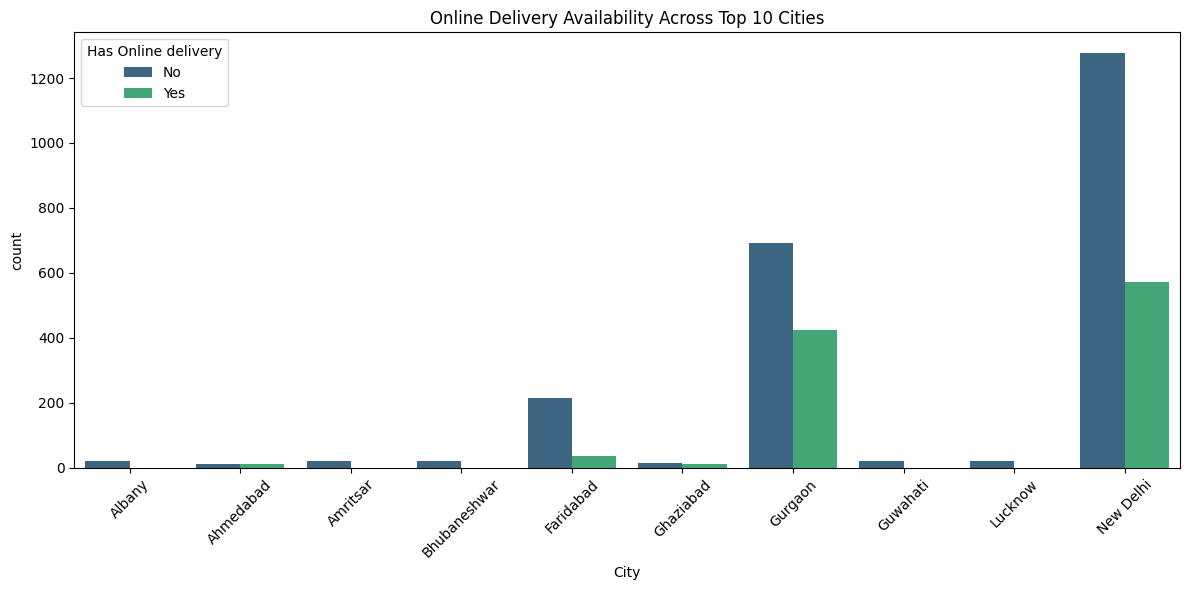

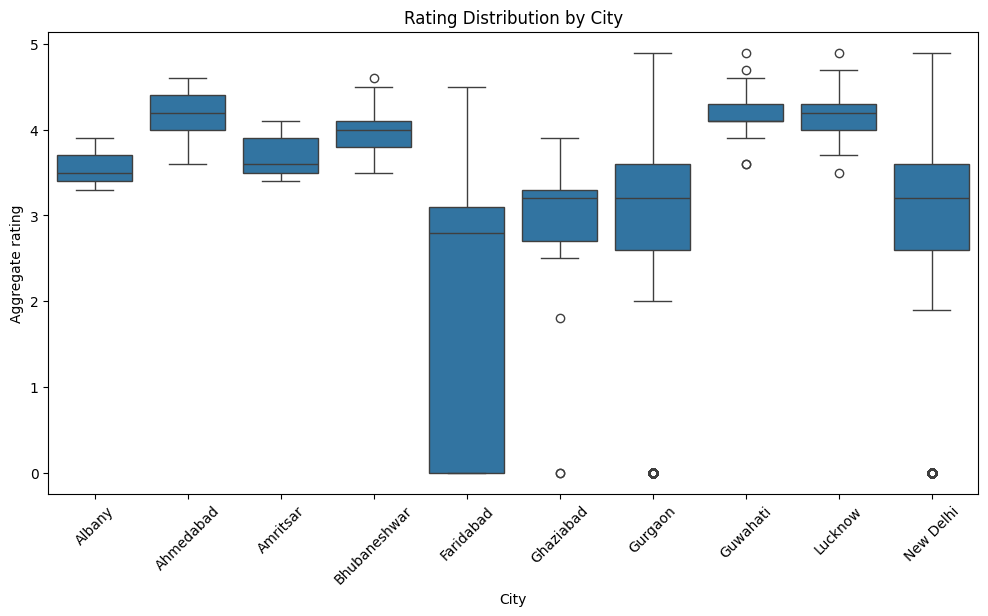

In [ ]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/Dataset .csv')

# --- TASK 1: Geospatial Analysis ---
# 1. Visualize restaurant locations using a map
# Note: We'll take a sample or focus on one city for better map performance
sample_map = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=2)
marker_cluster = MarkerCluster().add_to(sample_map)

for idx, row in df.dropna(subset=['Latitude', 'Longitude']).head(500).iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"{row['Restaurant Name']} - Rating: {row['Aggregate rating']}",
    ).add_to(marker_cluster)

# Save the map to an HTML file
sample_map.save('restaurant_map.html')
print("Geospatial Map saved as 'restaurant_map.html'")

# --- TASK 2: Service Optimization ---
# 2. Relationship between Location (City) and Service Availability (Online Delivery)
# Let's look at the top 10 cities by restaurant count
top_cities = df['City'].value_counts().nlargest(10).index
city_service_df = df[df['City'].isin(top_cities)]

plt.figure(figsize=(12, 6))
sns.countplot(data=city_service_df, x='City', hue='Has Online delivery', palette='viridis')
plt.title('Online Delivery Availability Across Top 10 Cities')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Correlation between Location and Rating
plt.figure(figsize=(12, 6))
sns.boxplot(data=city_service_df, x='City', y='Aggregate rating')
plt.title('Rating Distribution by City')
plt.xticks(rotation=45)
plt.show()